<a href="https://colab.research.google.com/github/jylee2930/DeepLearning-TensorFlow-Basic/blob/main/5_2_boston_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 라이브러리 환경

In [1]:
import pandas as pd
import numpy as np
import random
import tensorflow as tf
print(tf.__version__)

2.19.0


In [2]:
# 랜덤 시드 고정
SEED=12
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("시드 고정: ", SEED)

시드 고정:  12


In [6]:
housing = pd.read_csv('/content/boston.csv')
housing.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [9]:
# 2. 데이터 확인
print("shape:", housing.shape)        # (506, 14)
print(housing.head())

# 3. 피처(X)와 타겟(y) 분리
x_data = housing.drop(columns=["medv"])   # 13개 피처
y_data = housing["medv"]                   # 목적변수 MEDV

# 4. 확인
print("\nx_data shape:", x_data.shape)   # (506, 13)
print("y_data shape:", y_data.shape)     # (506,)

print("\nx_data 컬럼:", x_data.columns.tolist())
print("y_data 미리보기:\n", y_data.head())

shape: (506, 14)
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

x_data shape: (506, 13)
y_data shape: (506,)

x_data 컬럼: ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat']
y_data 미리보기:
 0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: medv, dtype: float64


In [12]:
##피쳐 스케일링
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_data_scaled = scaler.fit_transform(x_data)
X_data_scaled[0]

array([0.        , 0.18      , 0.06781525, 0.        , 0.31481481,
       0.57750527, 0.64160659, 0.26920314, 0.        , 0.20801527,
       0.28723404, 1.        , 0.08967991])

# 데이터 전처리

In [13]:
# 학습 - 테스트 데이터셋 분할
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_data_scaled, y_data,
                                                    test_size=0.2,
                                                    shuffle=True,
                                                    random_state=SEED)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(404, 13) (404,)
(102, 13) (102,)


# 신경망 학습

In [15]:
# 심층 신경망
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
##심층 신경망 모델(MLP)
model = Sequential([
    Dense(128, activation='relu', input_dim=13),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])




In [19]:

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,673 (49.50 KB)

 Trainable params: 12,673 (49.50 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# 모델 훈련
model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=2)

Epoch 1/100
13/13 - 2s - 139ms/step - loss: 573.2941 - mae: 22.0666
Epoch 2/100
13/13 - 0s - 5ms/step - loss: 524.3076 - mae: 20.8481
Epoch 3/100
13/13 - 0s - 7ms/step - loss: 406.7949 - mae: 17.5701
Epoch 4/100
13/13 - 0s - 6ms/step - loss: 215.5903 - mae: 11.7040
Epoch 5/100
13/13 - 0s - 6ms/step - loss: 140.6549 - mae: 9.4540
Epoch 6/100
13/13 - 0s - 6ms/step - loss: 108.3164 - mae: 7.9531
Epoch 7/100
13/13 - 0s - 7ms/step - loss: 90.2120 - mae: 7.1268
Epoch 8/100
13/13 - 0s - 5ms/step - loss: 72.8863 - mae: 6.3881
Epoch 9/100
13/13 - 0s - 6ms/step - loss: 62.0067 - mae: 5.7056
Epoch 10/100
13/13 - 0s - 6ms/step - loss: 54.8086 - mae: 5.3115
Epoch 11/100
13/13 - 0s - 6ms/step - loss: 50.1581 - mae: 5.0030
Epoch 12/100
13/13 - 0s - 6ms/step - loss: 46.5700 - mae: 4.7940
Epoch 13/100
13/13 - 0s - 6ms/step - loss: 43.3343 - mae: 4.6043
Epoch 14/100
13/13 - 0s - 6ms/step - loss: 40.2645 - mae: 4.4351
Epoch 15/100
13/13 - 0s - 11ms/step - loss: 37.3075 - mae: 4.2628
Epoch 16/100
13/13 - 

In [21]:
# 평가
model.evaluate(X_test, y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 11.7235 - mae: 2.4909 


[11.723483085632324, 2.4908814430236816]

# 교차 검증

In [22]:
history = model.fit(X_train, y_train, batch_size=32, epochs=200,
                    validation_split=0.25, verbose=2)

Epoch 1/200
10/10 - 0s - 17ms/step - loss: 8.3635 - mae: 2.0145 - val_loss: 7.9479 - val_mae: 1.9224
Epoch 2/200
10/10 - 0s - 13ms/step - loss: 8.0623 - mae: 1.9793 - val_loss: 8.2096 - val_mae: 1.9553
Epoch 3/200
10/10 - 0s - 12ms/step - loss: 7.9547 - mae: 1.9533 - val_loss: 8.2634 - val_mae: 1.9756
Epoch 4/200
10/10 - 0s - 12ms/step - loss: 7.8340 - mae: 1.9381 - val_loss: 8.2603 - val_mae: 1.9793
Epoch 5/200
10/10 - 0s - 12ms/step - loss: 7.6872 - mae: 1.9231 - val_loss: 8.3482 - val_mae: 1.9972
Epoch 6/200
10/10 - 0s - 12ms/step - loss: 7.5600 - mae: 1.9093 - val_loss: 8.3947 - val_mae: 2.0079
Epoch 7/200
10/10 - 0s - 11ms/step - loss: 7.4516 - mae: 1.8981 - val_loss: 8.4056 - val_mae: 2.0164
Epoch 8/200
10/10 - 0s - 12ms/step - loss: 7.3417 - mae: 1.8840 - val_loss: 8.3690 - val_mae: 2.0044
Epoch 9/200
10/10 - 0s - 12ms/step - loss: 7.2479 - mae: 1.8709 - val_loss: 8.3803 - val_mae: 2.0147
Epoch 10/200
10/10 - 0s - 16ms/step - loss: 7.1630 - mae: 1.8619 - val_loss: 8.4041 - val_m

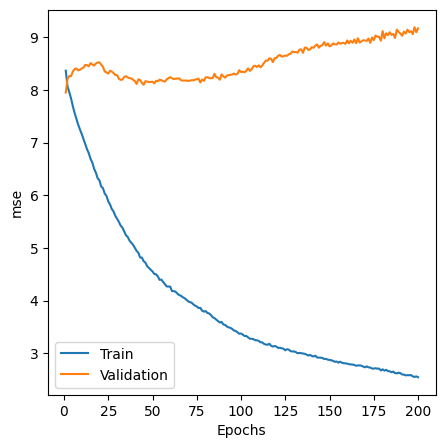

In [24]:
import matplotlib.pyplot as plt
def plot_loss_curve(total_epoch=10, start=1):
    plt.figure(figsize=(5, 5))
    plt.plot(range(start, total_epoch + 1),
             history.history['loss'][start-1:total_epoch],
             label='Train')
    plt.plot(range(start, total_epoch + 1),
             history.history['val_loss'][start-1:total_epoch],
             label='Validation')
    plt.xlabel('Epochs')
    plt.ylabel('mse')
    plt.legend()
    plt.show()

plot_loss_curve(total_epoch=200, start=1)

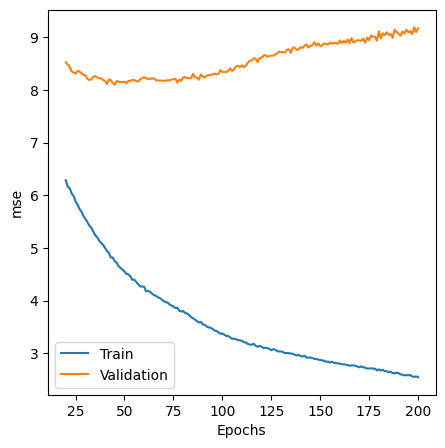

In [25]:
plot_loss_curve(total_epoch=200, start=20)

##DroupOut(0.3) 30%뉴런을 랜덤으로  off
##EarlySttopping 불필요한 학습 중단
##

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# 1. 데이터 분리 먼저
X_train, X_test, y_train, y_test = train_test_split(x_data, y_data,
                                                     test_size=0.2,
                                                     shuffle=True,
                                                     random_state=SEED)

# 2. 스케일링 (train fit, test transform)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. 모델 구성 (Dropout 추가)
model = Sequential([
    Dense(128, activation='relu', input_dim=13),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

# 4. 컴파일
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mse'])

# 5. EarlyStopping 적용
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# 6. 학습
history = model.fit(X_train_scaled, y_train,
                    batch_size=32,
                    epochs=200,
                    validation_split=0.25,
                    callbacks=[early_stop],
                    verbose=2)

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 - 5s - 503ms/step - loss: 574.8170 - mse: 574.8170 - val_loss: 536.7821 - val_mse: 536.7821
Epoch 2/200
10/10 - 1s - 85ms/step - loss: 533.7009 - mse: 533.7009 - val_loss: 482.4448 - val_mse: 482.4448
Epoch 3/200
10/10 - 0s - 28ms/step - loss: 453.5262 - mse: 453.5262 - val_loss: 366.0542 - val_mse: 366.0542
Epoch 4/200
10/10 - 0s - 28ms/step - loss: 302.5787 - mse: 302.5787 - val_loss: 177.7284 - val_mse: 177.7284
Epoch 5/200
10/10 - 0s - 31ms/step - loss: 122.4730 - mse: 122.4730 - val_loss: 60.8083 - val_mse: 60.8083
Epoch 6/200
10/10 - 0s - 27ms/step - loss: 74.5266 - mse: 74.5266 - val_loss: 44.9816 - val_mse: 44.9816
Epoch 7/200
10/10 - 0s - 22ms/step - loss: 58.2009 - mse: 58.2009 - val_loss: 33.5560 - val_mse: 33.5560
Epoch 8/200
10/10 - 0s - 36ms/step - loss: 36.7960 - mse: 36.7960 - val_loss: 28.3322 - val_mse: 28.3322
Epoch 9/200
10/10 - 0s - 36ms/step - loss: 34.7388 - mse: 34.7388 - val_loss: 24.8807 - val_mse: 24.8807
Epoch 10/200
10/10 - 1s - 61ms/step - loss: 37.0

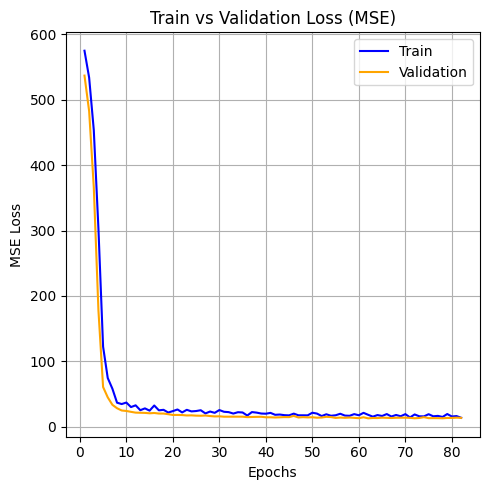

In [40]:
import matplotlib.pyplot as plt

def plot_loss_curve(total_epoch=None, start=1):

    # 실제 학습된 에폭 수 자동 감지 (EarlyStopping 대응)
    actual_epochs = len(history.history['loss'])
    if total_epoch is None:
        total_epoch = actual_epochs

    plt.figure(figsize=(5, 5))
    plt.plot(range(start, total_epoch + 1),
             history.history['loss'][start-1:total_epoch],
             label='Train', color='blue')
    plt.plot(range(start, total_epoch + 1),
             history.history['val_loss'][start-1:total_epoch],
             label='Validation', color='orange')

    plt.title('Train vs Validation Loss (MSE)')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 호출
plot_loss_curve()

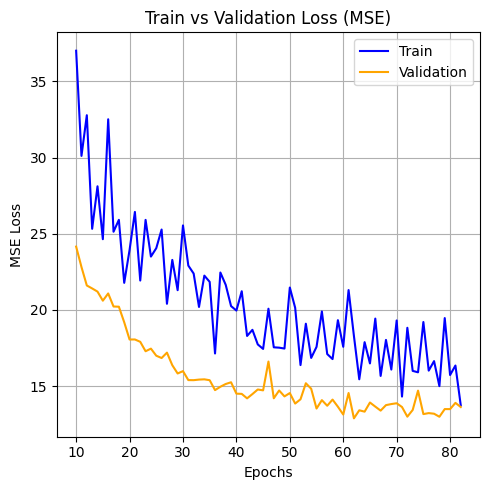

In [39]:
plot_loss_curve(total_epoch=None, start=10)

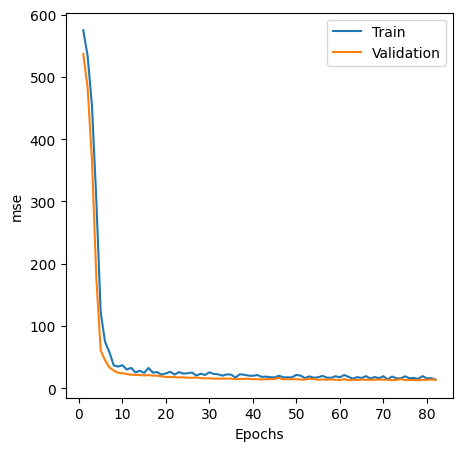

In [42]:
import matplotlib.pyplot as plt
def plot_loss_curve(total_epoch=10, start=1):
    plt.figure(figsize=(5, 5))
    plt.plot(range(start, total_epoch + 1),
             history.history['loss'][start-1:total_epoch],
             label='Train')
    plt.plot(range(start, total_epoch + 1),
             history.history['val_loss'][start-1:total_epoch],
             label='Validation')
    plt.xlabel('Epochs')
    plt.ylabel('mse')
    plt.legend()
    plt.show()

plot_loss_curve(total_epoch=len(history.history['loss']), start=1)

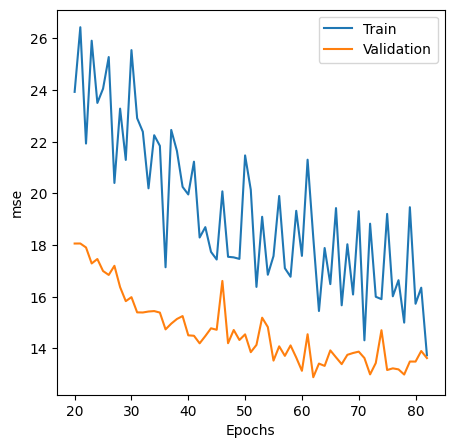

In [43]:
plot_loss_curve(total_epoch=len(history.history['loss']), start=20)